# More PyMC

The network we have built in PyMC is quite simple, featuring only binary valued discrete random variables and conditioning on single variables. To build real-world networks we need to understand how to build more complex models.

## Networks with Multiple Parents

Consider the following Bayesian network:

$P(X,Y,Z) = P(X)P(Y)P(Z\vert X,Y)$

for binary-valued random variables $X$, $Y$, $Z$ with associated distributions

|     | $P(X)$ |
|:----|:-------|
|$X=0$| $0.2$  |
|$X=1$| $0.8$  |


|     | $P(Y)$ |
|:----|:-------|
|$Y=0$| $0.9$  |
|$Y=1$| $0.1$  |


|     | $P(Z\vert X=0, Y=0)$ | $P(Z\vert X=0, Y=1)$ | $P(Z\vert X=1, Y=0)$ | $P(Z\vert X=1, Y=1)$ |
|:----|:---------------------|:---------------------|:---------------------|:---------------------|
|$X=0$| $0.3$                | $0.8$                | $0.9$                | $0.6$                |
|$X=1$| $0.7$                | $0.2$                | $0.1$                | $0.4$                |



When conditioning on a single variable, we created a deterministic variable from our input distribution using the `switch` command to select the correct column from our distribution. When conditioning on multiple variables, we have to do this multiple times until we have conditioned on all the variables.

In [30]:
import numpy as np
PX = np.array([0.2,0.8])
PY = np.array([0.9,0.1])
PZ_XY = np.array([[[0.3,0.8],[0.9,0.6]],[[0.7,0.2],[0.1,0.4]]])

In [31]:
import pymc as mc
with mc.Model() as model:
    X = mc.Bernoulli('X',PX[1])
    Y = mc.Bernoulli('Y',PY[1])
    PZ_X = mc.Deterministic('PZ_X', mc.math.switch(Y,PZ_XY[1,:,1],PZ_XY[1,:,0]))
    PZ = mc.Deterministic('PZ', mc.math.switch(X,PZ_X[1],PZ_X[0]))
    Z = mc.Bernoulli('Z', PZ)
    step = mc.Metropolis()
    trace = mc.sample(10000, step=step, tune=5000, random_seed=123, progressbar=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [X]
>Metropolis: [Y]
>Metropolis: [Z]


Output()

Sampling 4 chains for 5_000 tune and 10_000 draw iterations (20_000 + 40_000 draws total) took 12 seconds.


array([[<Axes: title={'center': 'X'}>, <Axes: title={'center': 'X'}>],
       [<Axes: title={'center': 'Y'}>, <Axes: title={'center': 'Y'}>],
       [<Axes: title={'center': 'Z'}>, <Axes: title={'center': 'Z'}>],
       [<Axes: title={'center': 'PZ_X'}>,
        <Axes: title={'center': 'PZ_X'}>],
       [<Axes: title={'center': 'PZ'}>, <Axes: title={'center': 'PZ'}>]],
      dtype=object)

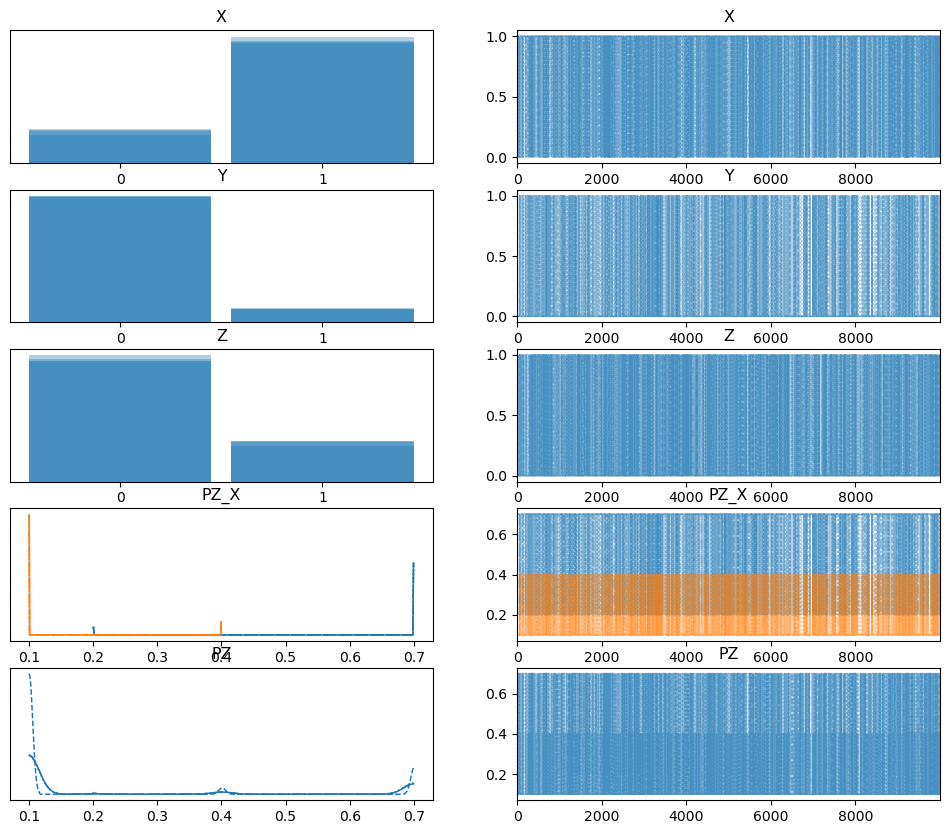

In [32]:
mc.plot_trace(trace)

Does this align with expectation? We can do the calculation analytically:

In [33]:
PZ_X = PZ_XY @ PY
PZ = PZ_X @ PX
print(PZ)

[0.766 0.234]


This looks correct compared to the graph from the trace, but let's calculate from the trace as well. We just want the number of times $Z=1$ in the trave divided by the number of rows in the trace

In [34]:
df = trace.to_dataframe(groups='posterior')
display(df)

,chain,draw,X,Y,Z,"(PZ_X[0], 0)","(PZ_X[1], 1)",PZ
0,0,0,1,0,0,0.7,0.1,0.1
1,0,1,1,0,0,0.7,0.1,0.1
2,0,2,1,0,0,0.7,0.1,0.1
3,0,3,1,0,0,0.7,0.1,0.1
4,0,4,1,0,0,0.7,0.1,0.1
...,...,...,...,...,...,...,...,...
39995,3,9995,0,1,1,0.2,0.4,0.2
39996,3,9996,0,1,1,0.2,0.4,0.2
39997,3,9997,0,1,0,0.2,0.4,0.2
39998,3,9998,0,1,0,0.2,0.4,0.2


In [35]:
display(df['Z'].mean())

np.float64(0.240575)

## Networks with Non-Binary variables

Let us now consider how to work with networks where the variables are discrete but non-binary valued. The analogue in PyMC of the Bernoulli distribution for non-binary discrete variables is the `Categorical` distribution. This takes a vector of probabilities, one per value. PyMC will automatically normalise this for us.

In [36]:
PX = np.array([1,2,3,4])

In [ ]:
with mc.Model() as model:
    X = mc.Categorical('X', PX)
    step = mc.Metropolis()
    trace = mc.sample(100000, step=step, tune=5000, random_seed=123, progressbar=True)

/opt/anaconda3/envs/pymc/lib/python3.13/site-packages/pymc/distributions/discrete.py:1142: UserWarning: `p` parameters sum to [10], instead of 1.0. They will be automatically rescaled. You can rescale them directly to get rid of this warning.
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
Metropolis: [X]


Output()

array([[<Axes: title={'center': 'X'}>, <Axes: title={'center': 'X'}>]],
      dtype=object)

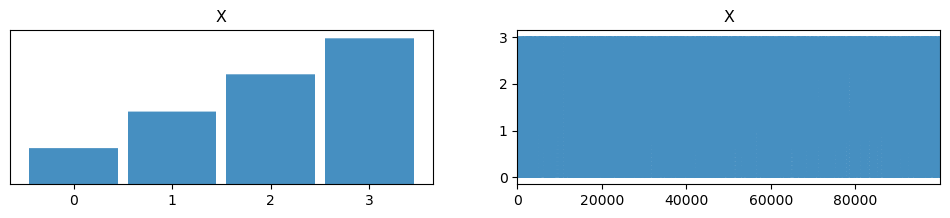

In [ ]:
mc.plot_trace(trace)

In [ ]:
df = trace.to_dataframe(groups='posterior')
display(df)

,chain,draw,X
0,0,0,2
1,0,1,2
2,0,2,2
3,0,3,2
4,0,4,2
...,...,...,...
399995,3,99995,3
399996,3,99996,2
399997,3,99997,1
399998,3,99998,1


In [ ]:
x = 3
p = len(df[df['X']==x])/len(df)
print(f"P(X={x}) = {p} (expected {PX[x]})")

P(X=3) = 0.40069 (expected 4)


We can use categorical variables just as we used binary variables to build networks, Consider the following (really simple) network:

$P(X,Y) = P(Y\vert X)P(X)$

where we have likelihoods

|       | $P(X)$ |
|:------|:-------|
| $X=0$ | $0.1$  |
| $X=1$ | $0.1$  |
| $X=2$ | $0.1$  |
| $X=3$ | $0.1$  |

and 

|       | $P(Y\vert X=0)$ | $P(Y\vert X=2)$ | $P(Y\vert X=2)$ | $P(Y\vert X=3)$ |
|:------|:----------------|:----------------|:----------------|:----------------|
| $Y=0$ | $0.7$           | $0.4$           | $0.2$           | $0.6$           |
| $Y=1$ | $0.2$           | $0.1$           | $0.5$           | $0.3$           |
| $Y=2$ | $0.1$           | $0.5$           | $0.3$           | $0.1$           |

In [ ]:
PX = np.array([0.1,0.2,0.3,0.4])
PY_X = np.array([[0.7,0.4,0.2,0.6],[0.2,0.1,0.5,0.3],[0.1,0.5,0.3,0.1]])

PY = PY_X@PX 
print(PY)

[0.45 0.31 0.24]


Implementing this requires a bit more thought: The `switch` instruction only allows us to selection based on a single condition:

`switch(cond, ifCondTrue, ifCondFalse)`

This is fine for binary variables, but doesn't work for multivalued variables. One option is to nest the switches together, but this will be very painful. One option would be use the function `numpy.take` which allows us to select a slice from a matrix:

In [ ]:
np.take(PY_X,3,axis=1)

array([0.6, 0.3, 0.1])


but this does not work because, as we saw before, we do not have the value of $X$ at the time this line of code would be executed. 

Fortunately, the `pytensor` package has a version of `take` that is compatible with PyMC:

In [ ]:
import pytensor.tensor as pt
pt.take(PY_X,3,axis=1)

Subtensor{:, i}.0

We can use this within a PyMC model in the following way:

In [ ]:
with mc.Model() as model:
    X = mc.Categorical('X',PX)
    PY = pt.take(PY_X, X, axis=1)
    Y = mc.Categorical('Y', PY)
    trace = mc.sample(10000, tune=5000, random_seed=123, progressbar=True)

Multiprocess sampling (4 chains in 4 jobs)
CategoricalGibbsMetropolis: [X, Y]


Output()

Sampling 4 chains for 0 tune and 15_000 draw iterations (0 + 60_000 draws total) took 2 seconds.


Note that this is not compatible with a `Metropolis` step. We will let PyMC work out what step to use instead.

Let's make sure it gives us what we expect:

array([[<Axes: title={'center': 'X'}>, <Axes: title={'center': 'X'}>],
       [<Axes: title={'center': 'Y'}>, <Axes: title={'center': 'Y'}>]],
      dtype=object)

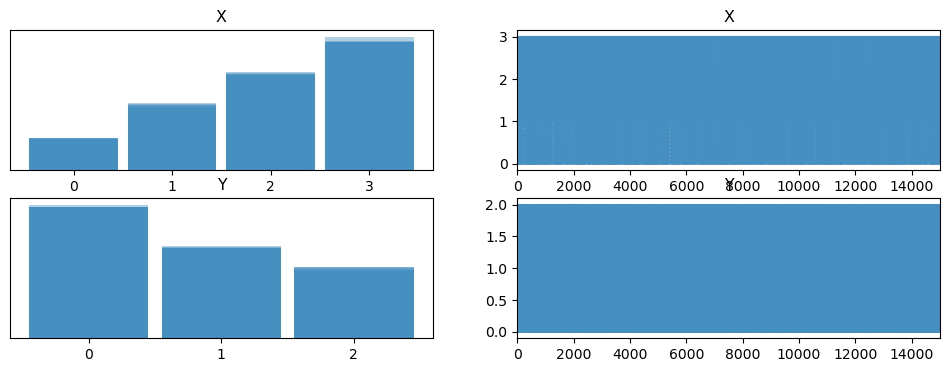

In [ ]:
mc.plot_trace(trace)

In [ ]:
df = trace.to_dataframe(groups='posterior')

df['Y']==1
for i in range(3):
    print(f"P(Y={i}) = {len(df[df['Y']==i])/len(df)} (expected {PY[i]})")

P(Y=0) = 0.45003333333333334 (expected Subtensor{i}.0)
P(Y=1) = 0.31055 (expected Subtensor{i}.0)
P(Y=2) = 0.23941666666666667 (expected Subtensor{i}.0)


## Networks with Continuous Variables

# Bayesian Networks with Continuous Variables

Our examples of Bayesian networks have so far been limited to networks of variables that are finite-valued, or discrete. It is very common for problems of interest to contain random variables that are not discrete, but are continuous, and are thus described not by a table of probabilities but by a probability density function, or PDF.

This creates a technical issue for us: we know very well how to multiply probability tables together, although this can become a formidable exercise in combinatorics. With continuous PDFs, we do not, in general know how to do this very easily (and sometime it is not possible at all. Approximate sampling is the only way we have of being able to calculate distributions.

In continuous Bayesian networks, we want to deduce the probability distribution of some continuous random variable (or variables) that depends on some other random variables, just as we are in the discrete case. In the discrete case, we work with conditional distributions and we do the same in the continuous case. Consider the following very simple example:

* A random variable $Y$ is known to be sampled from a normal distribution the mean of which is twice some other quantity $X$ and which has standard deviation $\sigma_Y$.
* $X$ is itself a random variable and is sampled from a normal distribution with mean $\mu_X$ and standard deviation $\sigma_X$.

Using the notation $\mathcal{N})(Z\vert \mu,\sigma)$ to denote a normally distributed random variable of mean $\mu$ and variance $\sigma^2$, we can write:

* The PDF of $X$ is therefore $P(X) = \mathcal{N}(X\vert \mu_X,\sigma_X)$
* The PDF of $Y$ is conditioned on $X$ and $P(Y\vert X, \sigma_Y)=\mathcal{N}(Y\vert 2X,\sigma_Y)$

The question is, how does the distribution of $X$ affect the distribution of $Y$? We do not yet have tools to answer this. Let us explore.

PyMC supports continuous random variables. Let us build a model.


In [ ]:
with mc.Model() as model:
    X = mc.Bernoulli('X',0.5)
    #Y = mc.Deterministic('Y', 5*X)
    Z = mc.Normal('Z', mu=5*X, sigma=1.0)
    trace = mc.sample(50000, tune=10000, random_seed=123, progressbar=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [X]
>NUTS: [Z]


Output()

Sampling 4 chains for 10_000 tune and 50_000 draw iterations (40_000 + 200_000 draws total) took 11 seconds.


array([[<Axes: title={'center': 'X'}>, <Axes: title={'center': 'X'}>],
       [<Axes: title={'center': 'Z'}>, <Axes: title={'center': 'Z'}>]],
      dtype=object)

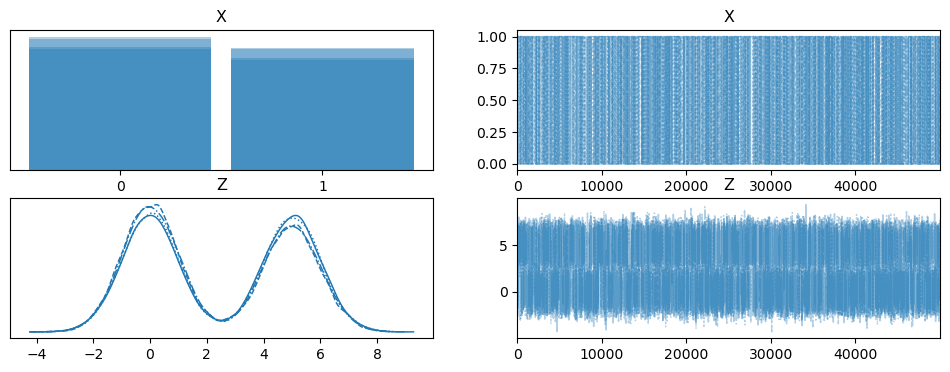

In [ ]:
mc.plot_trace(trace)

What happens if you change `mu=5*X` to `mu=10*X`? Essentially this is an artefact of the way the sampling is done (recall the Markov blanket). When there are well-separated "modes" in the distribution, many samplers can get stuck in one of the modes. It is therefore important to perform some check (such as by computing the input distributions) to check that that this hasn't occurred.

For a partial discuss of the issues, please see https://stats.stackexchange.com/questions/191014/gibbs-sampler-gets-stuck-in-local-mode. 

## A more complicated model

You are the manager of a store that sells coats and umbrellas. Your sales data indicates that people's buying habits have a pattern:

* They buy an umbrella when the weekly rainfall exceeds 12 (arbitrary units).
* They buy a coat when the weekly rainfall exceeds 5 a.u. or the weekly temperature drops below 8 a.u.

You would to predict the likelihood of an individual buying coats or umbrellas by season to have better control of your stock numbers so you decide to build a Bayesian network based on historic weather data to help you do this. The data tells your the following.

* There are four Seasons, each of equal length.
* The amount of weekly rainfall and the daily temperature depend on the seasons.
* It is assumed that temperature and rainfall are normally distributed and that the parameters take the following values:

|     | Spring | Summer | Autumn | Winter |
|:---:|:---:|:---:|:---:|:---:|
| $\mu_R$    | 12.0 | 10.0 | 15.0 | 20.0 |
| $\sigma_R$ | 4.0 | 2.0 | 5.0 | 3.0 |
| $\mu_T$    | 15.0 | 20.0 | 10.0 | 5.0 |
| $\sigma_T$ | 3.0 | 5.0 | 5.0 | 3.0 |



Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [Season]
>Metropolis: [Rainbase]
>Metropolis: [Tempbase]


Output()

Sampling 4 chains for 10_000 tune and 100_000 draw iterations (40_000 + 400_000 draws total) took 22 seconds.


array([[<Axes: title={'center': 'Season'}>,
        <Axes: title={'center': 'Season'}>],
       [<Axes: title={'center': 'Rainbase'}>,
        <Axes: title={'center': 'Rainbase'}>],
       [<Axes: title={'center': 'Tempbase'}>,
        <Axes: title={'center': 'Tempbase'}>],
       [<Axes: title={'center': 'Rain'}>,
        <Axes: title={'center': 'Rain'}>],
       [<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'Temperature'}>],
       [<Axes: title={'center': 'Umbrella'}>,
        <Axes: title={'center': 'Umbrella'}>],
       [<Axes: title={'center': 'Coat'}>,
        <Axes: title={'center': 'Coat'}>]], dtype=object)

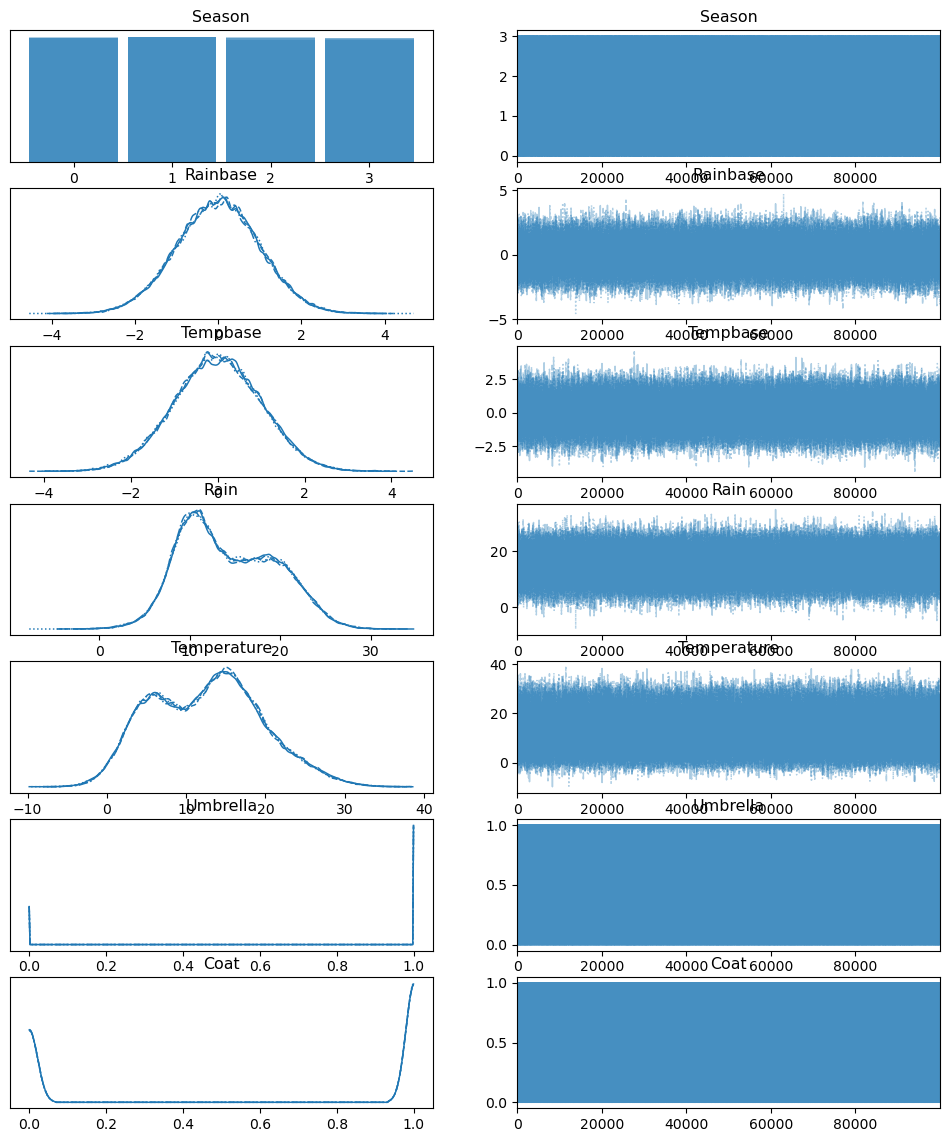

In [ ]:
with mc.Model() as model:
    # Seasons
    S = mc.Categorical('Season', np.array([0.25,0.25,0.25,0.25]))
    Rbase = mc.Normal('Rainbase', mu=0.0, sigma=1.0)
    Tbase = mc.Normal('Tempbase', mu=0.0, sigma=1.0)

    RMu = mc.math.switch(mc.math.eq(S,0),12.0, # Spring
            mc.math.switch(mc.math.eq(S,1),10.0, # Summer
                mc.math.switch(mc.math.eq(S,2),15.0, 20.0)
            )
        )
    
    RSigma = mc.math.switch(mc.math.eq(S,0),4.0, # Spring
                mc.math.switch(mc.math.eq(S,1),2.0, # Summer
                    mc.math.switch(mc.math.eq(S,2),5.0, 3.0)
                )
            )                               
    TMu = mc.math.switch(mc.math.eq(S,0),15.0, # Spring
            mc.math.switch(mc.math.eq(S,1),20.0, # Summer
                mc.math.switch(mc.math.eq(S,2),10.0, 5.0)
            )
        )
    
    TSigma = mc.math.switch(mc.math.eq(S,0),3.0, # Spring
                mc.math.switch(mc.math.eq(S,1),5.0, # Summer
                    mc.math.switch(mc.math.eq(S,2),5.0, 3.0)
                )
            )       

    
    R = mc.Deterministic('Rain', Rbase*RSigma+RMu)
    T = mc.Deterministic('Temperature', Tbase*TSigma+TMu)

    U = mc.Deterministic('Umbrella', mc.math.switch(mc.math.ge(R,10.0),1.0,0.0))
    C = mc.Deterministic('Coat', mc.math.switch(mc.math.ge(R,12.0),1.0,
                                               mc.math.switch(mc.math.lt(T,8.0),1.0, 0.0)
                                               )
                        )

    step = mc.Metropolis()
    trace = mc.sample(100000, step=step, tune=10000, random_seed=123, progressbar=True)

    
mc.plot_trace(trace)

In [ ]:
df=trace.to_dataframe(groups='posterior')

In [ ]:
Seasons = ['Spring','Summer','Autumn','Winter']
for i,s in enumerate(Seasons):
    P_Umbrella = float(df[(df['Season'] == i) & (df['Umbrella'] ==1)].shape[0]) / df[df['Season'] == i].shape[0]
    P_Coat = float(df[(df['Season'] == i) & (df['Coat'] ==1)].shape[0]) / df[df['Season'] == i].shape[0]
    print(f"P(Umbrella|{s}) = {P_Umbrella}")
    print(f"P(Coat|{s}) = {P_Coat}")

P(Umbrella|Spring) = 0.6932207623520008
P(Coat|Spring) = 0.5102762651746016
P(Umbrella|Summer) = 0.5013951640931433
P(Coat|Summer) = 0.16430167320391242
P(Umbrella|Autumn) = 0.8421021045050813
P(Coat|Autumn) = 0.8202168520444907
P(Umbrella|Winter) = 0.9997379930265836
P(Coat|Winter) = 0.9993651369490296


In [ ]:
PC = np.random.rand(30000)
PC = PC/PC.sum()
PP_C = np.random.rand(14000,30000)
PP_C = PP_C/PP_C.sum(axis=0)

with mc.Model() as model:
    C = mc.Categorical('C',PC)
    PP = pt.take(PP_C, C, axis=1)
    P = mc.Categorical('P', PP)
    trace = mc.sample(1000000, tune=5000, random_seed=123, progressbar=True)

Multiprocess sampling (4 chains in 4 jobs)
CategoricalGibbsMetropolis: [C, P]


Output()

Sampling 4 chains for 0 tune and 1_005_000 draw iterations (0 + 4_020_000 draws total) took 993 seconds.


array([[<Axes: title={'center': 'C'}>, <Axes: title={'center': 'C'}>],
       [<Axes: title={'center': 'P'}>, <Axes: title={'center': 'P'}>]],
      dtype=object)

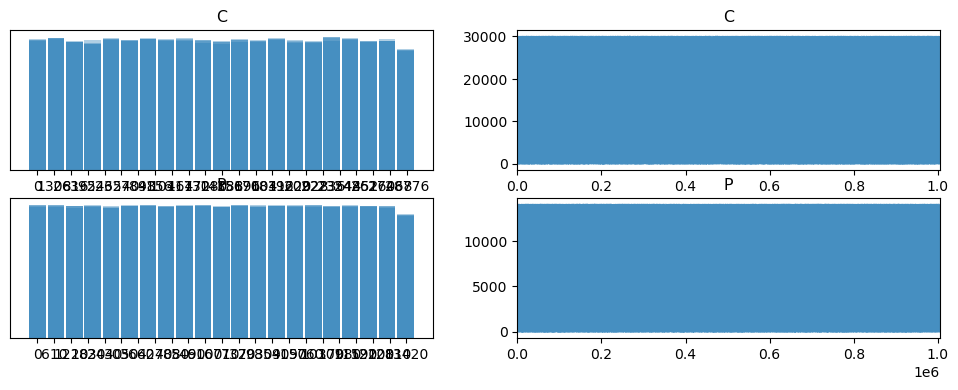

In [ ]:
mc.plot_trace(trace)